### Overview

Spectral indices are core to many remote sensing analysis. In this section, we will learn how can we perform calculations using XArray.

We will take a single Sentinel-2 scene and calculate spectral indices like NDVI, MNDWI and SAVI.

### Setup

Determine our runtime environment.

In [1]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

print(f'Environment: {environment}')

Environment: colab


If we are on Google Colab, install the required packages. Local runtimes are expected to have the packages already installed.

In [2]:
%%capture
if environment in ['colab', 'colab_enterprise']:
    !pip install pystac-client odc-stac rioxarray dask['distributed'] \
        jupyter-server-proxy

Import all required libraries. Make sure to import everything at the beginning as certain Xarray extensions are activated on import and registers certain accesors, like `.rio` and `.odc` for Xarray objects.

In [3]:
import dask
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pystac_client
import rioxarray as rxr
import xarray as xr
from odc.stac import configure_s3_access, load

Setup a local Dask cluster. This distributes the computation across multiple workers on your computer.

In [4]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:44435
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:36103'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40735'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:36105 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:36105
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:53104
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:36027 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:36027
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:53102
INFO:distributed.scheduler:Receive client connection: Client-3bfe8153-7ad0-11f1-82c8-0242ac1c000c
INFO:distributed.core:Starting establish

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44435,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36027,Total threads: 1
Dashboard: http://127.0.0.1:43143/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:36103,


If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [5]:
if environment == 'colab':
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))

https://8787-m-s-kkb-usw4a1-ejrl5zwledxu-a.us-west4-1.prod.colab.dev


### Get a Sentinel-2 Scene

We define a location and time of interest to get some satellite imagery.

In [6]:
latitude = 27.163
longitude = 82.608
year = 2023

Search the catalog for matching items.

In [7]:
# Define a GeoJSON geometry
geometry = {
    'type': 'Point',
    'coordinates': [longitude, latitude]
}

# Query the STAC Catalog
catalog = pystac_client.Client.open(
    'https://earth-search.aws.element84.com/v1')

search = catalog.search(
    collections=['sentinel-2-c1-l2a'],
    intersects=geometry,
    datetime=f'{year}',
    query={'eo:cloud_cover': {'lt': 30}, 's2:nodata_pixel_percentage': {'lt': 10}},
    sortby=[{'field': 'properties.eo:cloud_cover', 'direction': 'asc'}]
)
items = search.item_collection()

least_cloudy = items[0]

ds = load(
    [least_cloudy],
    bands=['red', 'green', 'blue', 'nir', 'swir16', 'swir22'],
    resolution=100, # Load the data at lower resolution to speed up processing
    crs='utm',
    chunks={'x': 1024, 'y': 1024},  # Explicitly define chunk sizes
    groupby='solar_day',
    preserve_original_order=True
)

scene = ds.squeeze()
# Mask nodata values
scene = scene.where(scene != 0)
# Apply scale/offset
scale = 0.0001
offset = -0.1
scene = scene*scale + offset
scene

/usr/local/lib/python3.12/dist-packages/pystac/extensions/storage.py:724: UserWarning: Could not parse bucket/account from href. The following assets were not migrated: ['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail']
  warnings.warn(


<xarray.Dataset> Size: 29MB
Dimensions:      (y: 1099, x: 1098)
Coordinates:
  * y            (y) float64 9kB 3.1e+06 3.1e+06 3.1e+06 ... 2.99e+06 2.99e+06
  * x            (x) float64 9kB 6e+05 6.002e+05 ... 7.096e+05 7.098e+05
    spatial_ref  int32 4B 32644
    time         datetime64[ns] 8B 2023-12-24T05:21:10.640000
Data variables:
    red          (y, x) float32 5MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    green        (y, x) float32 5MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    blue         (y, x) float32 5MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    nir          (y, x) float32 5MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    swir16       (y, x) float32 5MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    swir22       (y, x) float32 5MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>

Let's call `compute()` to kick-off the dask graph. Dask will query the cloud-hosted dataset to fetch the required pixels. Once you run the cell, look at the Dask Diagnostic Dashboard to see the data processing in action.

In [8]:
%%time
scene = scene.compute()

CPU times: user 340 ms, sys: 82.2 ms, total: 422 ms
Wall time: 5.28 s


### Visualize the Scene

To visualize our Dataset, we first convert it to a DataArray using the `to_array()` method. All the variables will be converted to a new dimension. Since our variables are image bands, we give the name of the new dimesion as band.


In [9]:
scene_da = scene.to_array('band')

Let's visualize a nature color band combination (RGB).

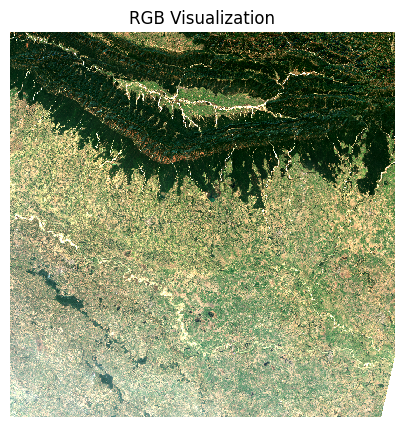

In [10]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5,5)
scene_da.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=ax,
    robust=True)
ax.set_title('RGB Visualization')
ax.set_axis_off()
ax.set_aspect('equal')
plt.show()

We can also view a False Color Composite (FCC) with a different combination of spectral bands.

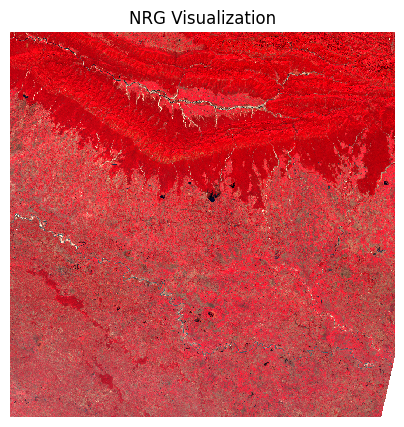

In [11]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5,5)
scene_da.sel(band=['nir', 'red', 'green']).plot.imshow(
    ax=ax,
    robust=True)
ax.set_title('NRG Visualization')
ax.set_axis_off()
ax.set_aspect('equal')
plt.show()

### Calculate Spectral Indices

The Normalized Difference Vegetation Index (NDVI) is calculated using the following formula:

`NDVI = (NIR - Red)/(NIR + Red)`

Where:

*   NIR = Near-Infrared band reflectance
*   Red = Red band reflectance

In [12]:
red = scene_da.sel(band='red')
nir = scene_da.sel(band='nir')

ndvi = (nir - red)/(nir + red)
ndvi

<xarray.DataArray (y: 1099, x: 1098)> Size: 5MB
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [0.7115468 , 0.35404107, 0.8269721 , ..., 0.45299155, 0.5046041 ,
        0.60218984],
       [0.60433394, 0.6694334 , 0.57258075, ..., 0.4156138 , 0.472909  ,
        0.665096  ],
       ...,
       [0.40544748, 0.27402523, 0.3734023 , ...,        nan,        nan,
               nan],
       [0.31823027, 0.31      , 0.27995756, ...,        nan,        nan,
               nan],
       [0.285835  , 0.35516784, 0.39704204, ...,        nan,        nan,
               nan]], dtype=float32)
Coordinates:
  * y            (y) float64 9kB 3.1e+06 3.1e+06 3.1e+06 ... 2.99e+06 2.99e+06
  * x            (x) float64 9kB 6e+05 6.002e+05 ... 7.096e+05 7.098e+05
    spatial_ref  int32 4B 32644
    time         datetime64[ns] 8B 2023-12-24T05:21:10.640000

Let's plot a histogram of the NDVI values.

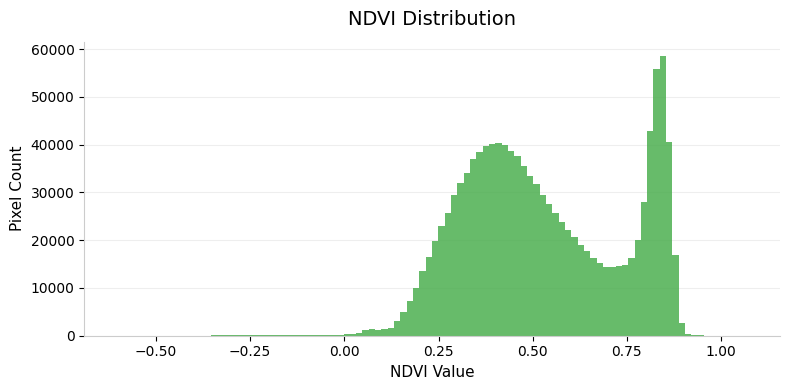

In [13]:
ndvi_values = ndvi.values.flatten()
ndvi_values = ndvi_values[~np.isnan(ndvi_values)]

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(8, 4)

ax.hist(ndvi_values, bins=100,
        color='#4CAF50', edgecolor='none', alpha=0.85)

ax.set_title('NDVI Distribution', fontsize=14, pad=12)
ax.set_xlabel('NDVI Value', fontsize=11)
ax.set_ylabel('Pixel Count', fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.yaxis.grid(True, color='#eeeeee', zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Let’s visualize the results. While the theoritical range of NDVI is between -1 and +1, most vegetation has NDVI values tend to be in the range 0-0.8. We can use this range to visualize the variation the vegetation better.

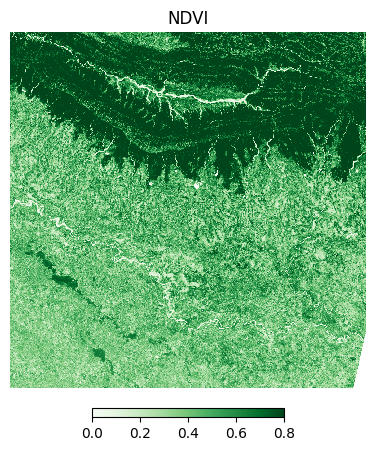

In [14]:
cbar_kwargs = {
    'orientation':'horizontal',
    'fraction': 0.025,
    'pad': 0.05,
    'extend':'neither'
}
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5,5)
ndvi.plot.imshow(
    ax=ax,
    cmap='Greens',
    vmin=0,
    vmax=0.8,
    cbar_kwargs=cbar_kwargs)
ax.set_title('NDVI')
ax.set_axis_off()
ax.set_aspect('equal')
plt.show()

The Modified Normalized Difference Water Index (MNDWI) is calculated using the following formula:

`MNDWI = (Green - SWIR1)/(Green + SWIR1)`

Where:

*   Green = Green band reflectance
*   SWIR1 = Short-wave infrared band 1 reflectance

In [15]:
green = scene_da.sel(band='green')
swir16 = scene_da.sel(band='swir16')
mndwi = (green - swir16)/(green + swir16)

Let's plot a histogram of the MNDWI values.

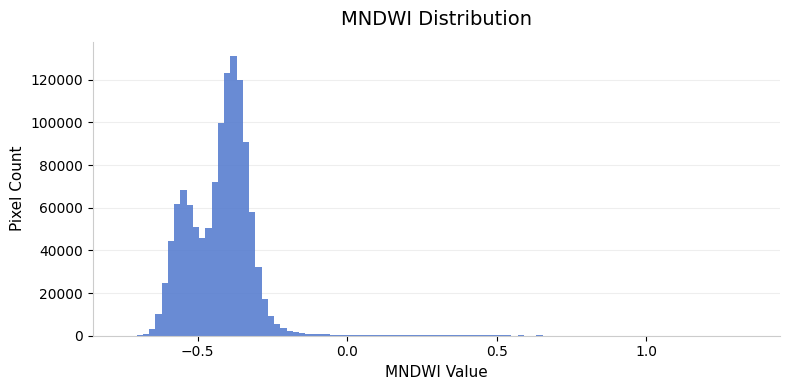

In [16]:
mndwi_values = mndwi.values.flatten()
mndwi_values = mndwi_values[~np.isnan(mndwi_values)]

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(8, 4)

ax.hist(mndwi_values, bins=100,
        color="#4F77CD", edgecolor='none', alpha=0.85)

ax.set_title('MNDWI Distribution', fontsize=14, pad=12)
ax.set_xlabel('MNDWI Value', fontsize=11)
ax.set_ylabel('Pixel Count', fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.yaxis.grid(True, color='#eeeeee', zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Visualize the MNDWI values.

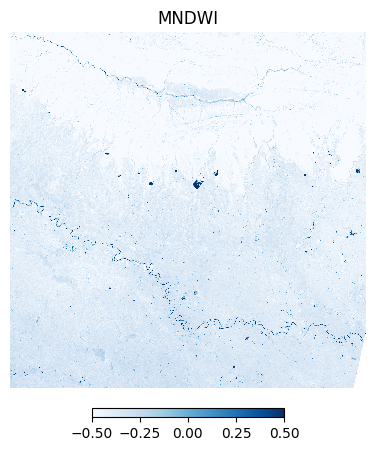

In [17]:
cbar_kwargs = {
    'orientation':'horizontal',
    'fraction': 0.025,
    'pad': 0.05,
    'extend':'neither'
}
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5,5)
mndwi.plot.imshow(
    ax=ax,
    cmap='Blues',
    vmin=-0.5,
    vmax=0.5,
    cbar_kwargs=cbar_kwargs)
ax.set_title('MNDWI')
ax.set_axis_off()
ax.set_aspect('equal')
plt.show()

The Soil Adjusted Vegetation Index (SAVI) is calculated using the following formula:


`SAVI = (1 + L) * ((NIR - Red)/(NIR + Red + L))`

Where:

*   NIR = Near-Infrared band reflectance
*   Red = Red band reflectance
*   L = Soil brightness correction factor (typically 0.5 for moderate vegetation)

In [18]:
savi = 1.5 * ((nir - red) / (nir + red + 0.5))

Close the dask client. This presents multiple clients being instantiated when running different notebooks on the same machine. This is not required on Colab but a good practice when you are running it on a local machine. Uncomment and run to shutdown the dask cluster.

In [19]:
#client.shutdown()

### Exercise

A simple technique for water detection is applying a threshold on the MNDWI image. Apply a threshold and create a water mask where all values above the threshold is 1, and others are set to 0.

Hint: Use the [`xarray.where`](https://docs.xarray.dev/en/stable/generated/xarray.where.html) function that allows you to set both matching and non-matching values.


In [20]:
threshold = 0
# Create a new array 'water' where all MNDWI values
#  greater than the threshold is 1 and others are 0
# Visualize the results.